# WattWise — Heuristic (Genetic Algorithm) for Battery Dispatch

Minimize the daily electricity bill by scheduling battery charging and discharging
in each 30-minute slot under CEB's Time-of-Use tariff.

**Method:** Genetic Algorithm (heuristic) — compared with the DP (exact method).

---

## Stage 1 — Data Loading

Load the cleaned 30-minute profiles into separate per-day arrays for solar, demand, and price.

### 1.1 Imports and data-loading functions

In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
# Constants used throughout the notebook
DATA_PATH = Path("cleaning/profiles_30min.csv")
SLOTS_PER_DAY = 48 # 30-minute slots
SLOT_HOURS = 0.5 # each slot is half an hour


def load_profiles(path=DATA_PATH):
    """Load the cleaned 30-minute profile data."""
    df = pd.read_csv(path)
    df["production_kWh"] = df["production_kWh"].astype(float)
    df["consumption_kWh"] = df["consumption_kWh"].astype(float)
    df["price_LKR_per_kWh"] = df["price_LKR_per_kWh"].astype(float)
    return df


def list_days(df):
    """Return all available dates in the dataset."""
    return sorted(df["date"].unique())


def get_day(df, date):
    """Return one day's data as clean 48-element NumPy arrays."""
    d = (
        df[df["date"] == date]
        .sort_values("slot_start")
        .reset_index(drop=True)
    )

    if len(d) != SLOTS_PER_DAY:
        raise ValueError(
            f"{date}: expected {SLOTS_PER_DAY} slots, got {len(d)}"
        )

    return {
        "date": date,
        "solar": d["production_kWh"].to_numpy(), # kWh generated per slot
        "demand": d["consumption_kWh"].to_numpy(), # kWh consumed per slot
        "price": d["price_LKR_per_kWh"].to_numpy(), # Rs/kWh for that slot
        "band": d["band"].to_numpy(),
        "slot": d["slot_start"].to_numpy(),
    }

### 1.2 Sanity check — load one day and inspect it

In [3]:
# sanity check
df = load_profiles()
print("Days available:", list_days(df))

day = get_day(df, "2026-09-11")
print(f"\nLoaded {day['date']}")
print(f"  slots       : {len(day['solar'])}")
print(f"  total solar : {day['solar'].sum():.2f} kWh")
print(f"  total demand: {day['demand'].sum():.2f} kWh")
print(f"  price levels: {sorted(set(day['price']))} Rs/kWh")

Days available: ['2026-09-10', '2026-09-11', '2026-09-13', '2026-09-16', '2026-09-17']

Loaded 2026-09-11
  slots       : 48
  total solar : 14.07 kWh
  total demand: 9.58 kWh
  price levels: [np.float64(33.0), np.float64(47.0), np.float64(106.0)] Rs/kWh


### 1.3 Inspect slots, bands and prices
See how the 48 slots map to tariff bands and prices, and where the bands switch.

In [4]:
day = get_day(df, "2026-09-11")

# full 48-slot table: index, time, band, price
print("idx  time    band       price")
print("-" * 34)
for i in range(SLOTS_PER_DAY):
    print(f"{i:>3}  {day['slot'][i]:>5}   {day['band'][i]:<9}  {day['price'][i]:>5.0f}")

# where do the bands change? (should land on 05:30, 18:30, 22:30)
print("\nBand transitions:")
prev = None
for i in range(SLOTS_PER_DAY):
    if day["band"][i] != prev:
        print(f"  slot {i:>2} ({day['slot'][i]}) -> {day['band'][i]} (Rs {day['price'][i]:.0f})")
        prev = day["band"][i]

# how many slots in each band
print("\nSlots per band:")
bands, counts = np.unique(day["band"], return_counts=True)
for b, n in zip(bands, counts):
    print(f"  {b:<9}: {n} slots")

idx  time    band       price
----------------------------------
  0  00:00   Off-Peak      33
  1  00:30   Off-Peak      33
  2  01:00   Off-Peak      33
  3  01:30   Off-Peak      33
  4  02:00   Off-Peak      33
  5  02:30   Off-Peak      33
  6  03:00   Off-Peak      33
  7  03:30   Off-Peak      33
  8  04:00   Off-Peak      33
  9  04:30   Off-Peak      33
 10  05:00   Off-Peak      33
 11  05:30   Day           47
 12  06:00   Day           47
 13  06:30   Day           47
 14  07:00   Day           47
 15  07:30   Day           47
 16  08:00   Day           47
 17  08:30   Day           47
 18  09:00   Day           47
 19  09:30   Day           47
 20  10:00   Day           47
 21  10:30   Day           47
 22  11:00   Day           47
 23  11:30   Day           47
 24  12:00   Day           47
 25  12:30   Day           47
 26  13:00   Day           47
 27  13:30   Day           47
 28  14:00   Day           47
 29  14:30   Day           47
 30  15:00   Day           47
 31  

---

## Stage 2 — Battery Simulation & Bill Calculation

This is the core of the project: a function that takes a battery schedule (48 actions) and a battery size, simulates the battery throughout the day, and returns the electricity bill. This bill **is the objective function** that the GA will minimize.

**Sign convention:** positive action = discharge, negative = charge.


### 2.1 Battery constants (shared with the DP — keep identical)

In [5]:
# Battery model parameters (README spec; match Kasun's DP)
CAPACITIES = [0, 2, 4, 7]  # kWh (the capacity sweep)
SLOT_HOURS = 0.5            # 30-min slots

SOC_RESERVE_FRAC = 0.2      # 20% reserve: SoC stays in [0.2C, C]

CHARGE_RATE_KW = 2.2        # R_c — charge power limit (verify vs datasheet)
DISCHARGE_RATE_KW = 2.5     # R_d — discharge power limit (verify)
MAX_CHARGE_KWH = CHARGE_RATE_KW * SLOT_HOURS        # = 1.10 kWh/slot
MAX_DISCHARGE_KWH = DISCHARGE_RATE_KW * SLOT_HOURS   # = 1.25 kWh/slot

ETA_C = 0.95  # charge efficiency — PLACEHOLDER, confirm with Kasun
ETA_D = 0.95  # discharge efficiency — PLACEHOLDER, confirm with Kasun

PENALTY = 1000.0  # constraint-violation penalty weight

### 2.2 The simulation + bill function (the objective)

Converts a battery **schedule** (48 actions) into an **electricity bill** — this is the
objective function the GA minimizes. Walking slot by slot, it tracks the battery level
(SoC), checks the rules (rate, capacity), and sums the grid cost each slot.

**Returns:** `bill` (Rs), `violation` (0 if legal), `feasible` (bool), `soc` (battery level per slot).

In [6]:
def simulate(schedule, day, capacity, eta_c=ETA_C, eta_d=ETA_D,
             max_charge=MAX_CHARGE_KWH, max_discharge=MAX_DISCHARGE_KWH,
             reserve_frac=SOC_RESERVE_FRAC):
    """
    Simulate one day's dispatch. Returns bill, violation, feasible, soc.
    Model per README: 20% SoC reserve, two-way efficiency, asymmetric rate limits.
    """
    schedule = np.asarray(schedule, dtype=float)
    solar, demand, price = day["solar"], day["demand"], day["price"]

    soc_min, soc_max = reserve_frac * capacity, capacity
    soc = soc_min  # start at the reserve floor
    soc_traj = np.zeros(SLOTS_PER_DAY)
    bill = 0.0
    violation = 0.0

    for t in range(SLOTS_PER_DAY):
        a = schedule[t]

        # Rate limits (asymmetric: charge vs discharge)
        if a >= 0:  # discharge
            if a > max_discharge:
                violation += a - max_discharge
        else:  # charge
            if -a > max_charge:
                violation += (-a) - max_charge

        # SoC transition with efficiency BOTH ways (README)
        if a >= 0:
            soc = soc - a / eta_d  # discharge: draw a/η_d from battery
        else:
            soc = soc + eta_c * (-a)  # charge: store η_c·|a|

        # Capacity limits with 20% reserve
        if soc < soc_min:
            violation += soc_min - soc
        if soc > soc_max:
            violation += soc - soc_max
        soc_traj[t] = soc

        # Grid energy + cost (no export; surplus curtailed at zero value)
        grid = demand[t] - solar[t] - a
        bill += max(grid, 0.0) * price[t]

    return {
        "bill": bill,
        "violation": violation,
        "feasible": violation < 1e-9,
        "soc": soc_traj
    }

**Run the simulation on a do-nothing schedule (should match the no-battery baseline)**

In [7]:
day = get_day(df, "2026-09-11")

# run the simulation on a do-nothing schedule (should match the no-battery baseline)
result = simulate(np.zeros(SLOTS_PER_DAY), day, capacity=4)

# inspect what the function returns
print("Keys returned:", list(result.keys()))
print(f"  bill      : Rs {result['bill']:.2f}")
print(f"  violation : {result['violation']:.3f}")
print(f"  feasible  : {result['feasible']}")
print(f"  soc       : array of {len(result['soc'])} values (battery level each slot)")
print(f"  soc[:5]   : {result['soc'][:5]}") # there are 48 values

Keys returned: ['bill', 'violation', 'feasible', 'soc']
  bill      : Rs 160.91
  violation : 0.000
  feasible  : True
  soc       : array of 48 values (battery level each slot)
  soc[:5]   : [0.8 0.8 0.8 0.8 0.8]


---

## Stage 3 — Constraint Penalties → Fitness Function

The GA minimizes **fitness**, not the raw bill. Fitness is the bill **plus a penalty** for any rule violations:

> **fitness = bill + P × violation**

A feasible schedule (violation = 0) keeps its true bill. An infeasible schedule gets a large penalty added, so the GA avoids it, even if its raw bill looks cheap (for example, by using energy the battery does not have).

This is the **graded penalty** method: the penalty increases with *how badly* a schedule breaks the rules, giving the GA a direction back toward feasibility.


### 3.1 The fitness function

In [18]:
PENALTY = 1000.0  # penalty weight P; large enough that no infeasible schedule can win

def fitness(schedule, day, capacity, penalty=PENALTY):
    """
    The value the GA minimizes.
    fitness = bill + penalty * violation
    Feasible schedules (violation=0) keep their true bill; infeasible ones are pushed up.
    """
    res = simulate(schedule, day, capacity)
    res["fitness"] = res["bill"] + penalty * res["violation"]
    return res

### 3.2 Check the penalty makes infeasible schedules lose

In [19]:
day = get_day(df, "2026-09-11")

def report(name, r):
    print(f"{name:<28} bill={r['bill']:>8.2f}  "
          f"violation={r['violation']:>7.2f}  feasible={str(r['feasible']):>5}  "
          f"fitness={r['fitness']:>10.2f}")

# a feasible saving schedule
good = np.zeros(SLOTS_PER_DAY)
for t in [20, 22, 24, 26, 28]: good[t] = -0.5
for t in range(37, 45): good[t] = +0.12

# an infeasible "cheat" schedule (discharges from an empty battery)
cheat = np.zeros(SLOTS_PER_DAY)
cheat[0] = 1.0
cheat[1] = 1.0

report("do-nothing (feasible)", fitness(np.zeros(SLOTS_PER_DAY), day, 4))
report("sensible saver (feasible)", fitness(good, day, 4))
report("cheat: empty discharge", fitness(cheat, day, 4))

do-nothing (feasible)        bill=  160.91  violation=   0.00  feasible= True  fitness=    160.91
sensible saver (feasible)    bill=  146.59  violation=   0.00  feasible= True  fitness=    146.59
cheat: empty discharge       bill=  147.02  violation=  95.00  feasible=False  fitness=  95147.02


The penalty works. The feasible **sensible saver** (Rs 146.59) beats the Rs 160.91 baseline and keeps its low fitness. The **cheat** looks cheap (Rs 147.02) but discharges energy the battery never had. Its violation of 95 pushes the fitness to around 95,000, so the GA rejects it.


---

## Stage 4 — The Genetic Algorithm (Heuristic Optimizer)

Evolve a population of 48-slot schedules toward the cheapest feasible one. Each generation uses **tournament selection** → **blend crossover** → **Gaussian mutation** → **elitism**.

The GA minimizes the `fitness` from Stage 3 (bill + penalty).


### 4.1 Warm-starting the population with a greedy schedule
Instead of starting the GA from pure random noise, we seed the population with **one** sensible
rule-based schedule (charge surplus solar, discharge at peak). This speeds up convergence and
improves the final answer, while seeding just one keeps the population diverse. It also doubles
as a simple baseline.

In [ ]:
def greedy_schedule(day, capacity, eta_c=ETA_C, eta_d=ETA_D,
                    max_charge=MAX_CHARGE_KWH, max_discharge=MAX_DISCHARGE_KWH,
                    reserve_frac=SOC_RESERVE_FRAC):
    """Feasible greedy seed respecting reserve, efficiency, and asymmetric rates."""
    s = np.zeros(SLOTS_PER_DAY)
    soc_min, soc_max = reserve_frac * capacity, capacity
    soc = soc_min

    for t in range(SLOTS_PER_DAY):
        surplus = day["solar"][t] - day["demand"][t]

        if surplus > 0:  # charge from surplus
            room = soc_max - soc
            charge = min(surplus, max_charge, room / eta_c if eta_c > 0 else room)
            charge = max(charge, 0.0)
            s[t] = -charge
            soc += eta_c * charge

        elif day["price"][t] >= 100:  # discharge at peak
            avail = soc - soc_min
            discharge = min(day["demand"][t], max_discharge, avail * eta_d)
            discharge = max(discharge, 0.0)
            s[t] = discharge
            soc -= discharge / eta_d

    return s

***Test the greedy seed***

Check it produces a feasible schedule and a sensible bill across all battery sizes.

In [23]:
day = get_day(df, "2026-09-11")
baseline = 160.91

print("Greedy seed check (Sep 11):")
for cap in CAPACITIES:  # [0, 2, 4, 7]
    g = greedy_schedule(day, cap)
    r = simulate(g, day, cap)
    saving = baseline - r["bill"]
    print(f"  cap={cap} kWh :  bill = Rs {r['bill']:6.2f}   "
          f"feasible={r['feasible']}   saving = Rs {saving:5.2f} "
          f"({100*saving/baseline:4.1f}%)")

# show the greedy schedule for one capacity, slot by slot
print("\nGreedy schedule for 4 kWh battery (non-zero slots only):")
print(f"{'slot':>4} {'time':>5} {'band':<9} {'action':>8}  what")

g = greedy_schedule(day, 4)
for t in range(SLOTS_PER_DAY):
    if abs(g[t]) > 1e-9:  # only show slots where something happens
        action = "charge " if g[t] < 0 else "discharge"
        print(f"{t:>4} {day['slot'][t]:>5} {day['band'][t]:<9} {g[t]:>+8.2f}  {action} {abs(g[t]):.2f} kWh")

Greedy seed check (Sep 11):
  cap=0 kWh :  bill = Rs 160.91   feasible=True   saving = Rs -0.00 (-0.0%)
  cap=2 kWh :  bill = Rs  92.54   feasible=True   saving = Rs 68.37 (42.5%)
  cap=4 kWh :  bill = Rs  92.54   feasible=True   saving = Rs 68.37 (42.5%)
  cap=7 kWh :  bill = Rs  92.54   feasible=True   saving = Rs 68.37 (42.5%)

Greedy schedule for 4 kWh battery (non-zero slots only):
slot  time band        action  what
  13 06:30 Day          -0.10  charge  0.10 kWh
  14 07:00 Day          -0.35  charge  0.35 kWh
  15 07:30 Day          -0.66  charge  0.66 kWh
  16 08:00 Day          -0.94  charge  0.94 kWh
  17 08:30 Day          -0.48  charge  0.48 kWh
  18 09:00 Day          -0.43  charge  0.43 kWh
  19 09:30 Day          -0.88  charge  0.88 kWh
  20 10:00 Day          -0.53  charge  0.53 kWh
  21 10:30 Day          -0.05  charge  0.05 kWh
  22 11:00 Day          -0.01  charge  0.01 kWh
  23 11:30 Day          -0.00  charge  0.00 kWh
  24 12:00 Day          -0.00  charge  0.00 kW

### 4.2 The Genetic Algorithm
Evolve the population with tournament selection, blend crossover, Gaussian mutation,
and elitism — minimizing the penalized fitness over many generations.

In [ ]:
def run_ga(day, capacity, pop_size=100, generations=200, cx_rate=0.8,
           mut_rate=0.1, mut_sigma=0.2, tournament_k=3, elites=2, seed=0):
    """Genetic Algorithm. Returns the best schedule, bill, feasibility, and history."""
    rng = np.random.default_rng(seed)

    # initial population: mostly small-random, plus a greedy seed and a zero seed
    pop = rng.normal(0, 0.3, size=(pop_size, SLOTS_PER_DAY)).clip(-MAX_CHARGE_KWH, MAX_DISCHARGE_KWH)
    pop[0] = greedy_schedule(day, capacity)  # warm-start seed
    pop[1] = 0.0  # do-nothing seed (always feasible)
    fits = np.array([fitness(ind, day, capacity)["fitness"] for ind in pop])
    history = []

    def tournament():
        idx = rng.integers(0, pop_size, tournament_k)
        return pop[idx[np.argmin(fits[idx])]]  # fittest of k random individuals

    for g in range(generations):
        order = np.argsort(fits)
        next_pop = [pop[order[i]].copy() for i in range(elites)]  # keep best few

        while len(next_pop) < pop_size:
            p1, p2 = tournament(), tournament()

            if rng.random() < cx_rate:
                a = rng.random(SLOTS_PER_DAY)
                child = a * p1 + (1 - a) * p2  # blend (arithmetic) crossover
            else:
                child = p1.copy()

            m = rng.random(SLOTS_PER_DAY) < mut_rate  # Gaussian mutation
            child[m] += rng.normal(0, mut_sigma, size=m.sum())
            child = child.clip(-MAX_CHARGE_KWH, MAX_DISCHARGE_KWH)  # clamp to charge/discharge rate limits
            next_pop.append(child)

        pop = np.array(next_pop)
        fits = np.array([fitness(ind, day, capacity)["fitness"] for ind in pop])
        history.append(fits.min())

    best = pop[np.argmin(fits)]
    res = fitness(best, day, capacity)

    return {
        "schedule": best,
        "bill": res["bill"],
        "feasible": res["feasible"],
        "violation": res["violation"],
        "fitness": res["fitness"],
        "soc": res["soc"],
        "history": history
    }

### 4.3 Run the GA on one scenario

A scenario is one (day + battery size) combination. Here, we test the GA on a single scenario, Sep 11 with a 4 kWh battery, to check that it converges and finds a feasible, cheaper schedule before running all 20 scenarios (5 days × 4 sizes) in Stage 5.

In [25]:
day = get_day(df, "2026-09-11")
baseline = 160.91
result = run_ga(day, capacity=4, seed=1)

print("GA result (Sep 11, 4 kWh battery)")
print(f"  bill      : Rs {result['bill']:.2f}")
print(f"  feasible  : {result['feasible']}")
print(f"  vs no-battery (Rs {baseline}) : saving Rs {baseline - result['bill']:.2f} "
      f"({100*(baseline - result['bill'])/baseline:.1f}%)")
print(f"  vs greedy (Rs 92.54)          : Rs {92.54 - result['bill']:.2f} cheaper")
print(f"  convergence : gen0={result['history'][0]:.1f} -> "
      f"gen50={result['history'][49]:.1f} -> gen199={result['history'][-1]:.1f}")

GA result (Sep 11, 4 kWh battery)
  bill      : Rs 53.59
  feasible  : True
  vs no-battery (Rs 160.91) : saving Rs 107.32 (66.7%)
  vs greedy (Rs 92.54)          : Rs 38.95 cheaper
  convergence : gen0=92.5 -> gen50=54.0 -> gen199=53.6


***View the optimized schedule***

In [26]:
# show the GA's optimized schedule (the solution)
sch = result["schedule"]
soc = result["soc"]

print("GA optimized schedule (Sep 11, 4 kWh) — active slots only:")
print(f"{'slot':>4} {'time':>5} {'band':<9} {'action':>8}  {'what':<18} {'SoC':>5}")

for t in range(SLOTS_PER_DAY):
    if abs(sch[t]) > 0.02:  # skip near-idle slots
        act = "charge" if sch[t] < 0 else "discharge"
        what = f"{act} {abs(sch[t]):.2f} kWh"
        print(f"{t:>4} {day['slot'][t]:>5} {day['band'][t]:<9} "
              f"{sch[t]:>+8.2f}  {what:<18} {soc[t]:>5.2f}")

GA optimized schedule (Sep 11, 4 kWh) — active slots only:
slot  time band        action  what                 SoC
   0 00:00 Off-Peak     -0.13  charge 0.13 kWh     0.12
   1 00:30 Off-Peak     -0.11  charge 0.11 kWh     0.22
   2 01:00 Off-Peak     +0.04  discharge 0.04 kWh  0.18
   3 01:30 Off-Peak     +0.09  discharge 0.09 kWh  0.09
   4 02:00 Off-Peak     -0.07  charge 0.07 kWh     0.15
   5 02:30 Off-Peak     -0.12  charge 0.12 kWh     0.25
   6 03:00 Off-Peak     -0.05  charge 0.05 kWh     0.30
   7 03:30 Off-Peak     +0.03  discharge 0.03 kWh  0.27
   8 04:00 Off-Peak     +0.07  discharge 0.07 kWh  0.20
  11 05:30 Day          +0.12  discharge 0.12 kWh  0.06
  12 06:00 Day          +0.03  discharge 0.03 kWh  0.03
  13 06:30 Day          -0.09  charge 0.09 kWh     0.11
  14 07:00 Day          -0.32  charge 0.32 kWh     0.40
  15 07:30 Day          -0.53  charge 0.53 kWh     0.87
  16 08:00 Day          -0.73  charge 0.73 kWh     1.53
  17 08:30 Day          -0.28  charge 0.28 kW

---
## Stage 5 — Experiments & Plots

Run the GA across the full sweep (4 battery sizes × 5 days = 20 scenarios), each with
multiple random seeds for rigor. Collect the results and visualize them.

### 5.1 Run the full capacity sweep (20 scenarios × seeds)

Run the GA on all 20 scenarios (5 days × 4 sizes), 3 seeds each, and record the bills and savings.

In [27]:
import time

DAYS = list_days(df)  # all 5 dates
SEEDS = [1, 2, 3]    # multiple seeds since the GA is stochastic

rows = []
t0 = time.time()

for date in DAYS:
    day = get_day(df, date)
    baseline = simulate(np.zeros(SLOTS_PER_DAY), day, 0)["bill"]  # no-battery bill

    for cap in CAPACITIES:  # [0, 2, 4, 7]
        bills = [run_ga(day, cap, seed=s)["bill"] for s in SEEDS]

        rows.append({
            "date": date,
            "capacity": cap,
            "baseline": round(baseline, 1),
            "ga_mean": round(np.mean(bills), 1),
            "ga_best": round(np.min(bills), 1),
            "saving_pct": round(100 * (baseline - np.min(bills)) / baseline, 1)
                if baseline > 0 else 0.0,
        })

results = pd.DataFrame(rows)

print(f"Completed {len(DAYS) * len(CAPACITIES) * len(SEEDS)} GA runs in {time.time()-t0:.1f}s\n")
print(results.to_string(index=False))

Completed 60 GA runs in 70.5s

      date  capacity  baseline  ga_mean  ga_best  saving_pct
2026-09-10         0     338.7    338.7    338.7         0.0
2026-09-10         2     338.7    133.9    133.9        60.5
2026-09-10         4     338.7     91.3     87.8        74.1
2026-09-10         7     338.7     77.2     75.4        77.7
2026-09-11         0     160.9    160.9    160.9         0.0
2026-09-11         2     160.9     74.8     68.0        57.7
2026-09-11         4     160.9     53.2     52.2        67.5
2026-09-11         7     160.9     52.6     52.2        67.6
2026-09-13         0     187.3    187.3    187.3         0.0
2026-09-13         2     187.3     81.4     79.8        57.4
2026-09-13         4     187.3     70.2     68.9        63.2
2026-09-13         7     187.3     70.3     67.6        63.9
2026-09-16         0     158.8    158.8    158.8         0.0
2026-09-16         2     158.8     55.3     54.6        65.6
2026-09-16         4     158.8     43.9     42.9      

### 5.2 Summary — average saving by battery size

In [28]:
summary = results.groupby("capacity").agg(
    avg_bill=("ga_best", "mean"),
    avg_saving_pct=("saving_pct", "mean")
).round(1)

print("Average across the 5 days:")
print(summary.to_string())

Average across the 5 days:
          avg_bill  avg_saving_pct
capacity                          
0            196.7             0.0
2             79.0            59.7
4             59.0            69.3
7             56.2            70.2


### 5.4 Plot 2 — Optimized dispatch schedule

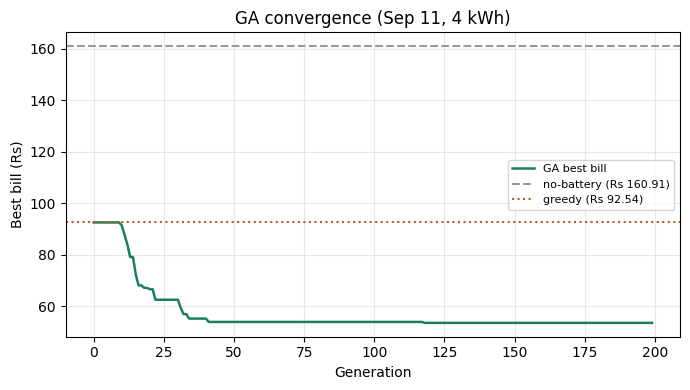

In [30]:
import matplotlib.pyplot as plt

day = get_day(df, "2026-09-11")
r = run_ga(day, capacity=4, seed=1)

plt.figure(figsize=(7, 4))
plt.plot(r["history"], color="#1a7f5a", lw=1.8, label="GA best bill")
plt.axhline(160.91, ls="--", color="#999", label="no-battery (Rs 160.91)")
plt.axhline(92.54, ls=":", color="#c0562a", label="greedy (Rs 92.54)")

plt.xlabel("Generation")
plt.ylabel("Best bill (Rs)")
plt.title("GA convergence (Sep 11, 4 kWh)")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.4 Plot 2 — Optimized dispatch schedule

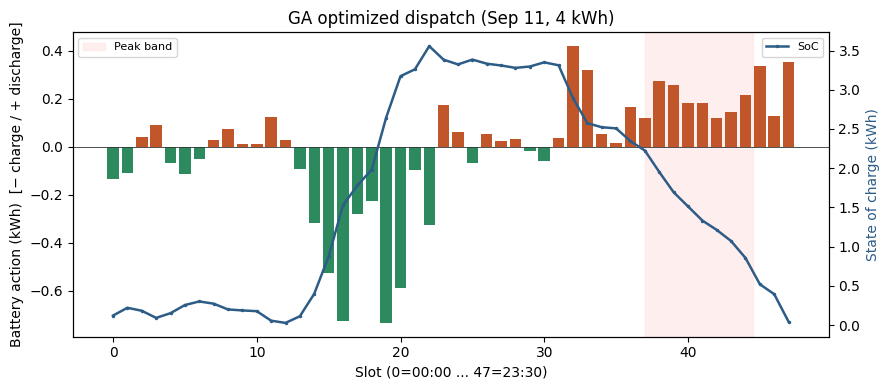

In [31]:
sch, soc = r["schedule"], r["soc"]
x = np.arange(SLOTS_PER_DAY)

fig, ax1 = plt.subplots(figsize=(9, 4))
colors = ["#2d8a5f" if a < 0 else "#c0562a" for a in sch]   # green=charge, red=discharge
ax1.bar(x, sch, color=colors, width=0.8)
ax1.axhline(0, color="#333", lw=0.6)
ax1.axvspan(37, 44.5, color="#ffdede", alpha=0.5, zorder=0, label="Peak band")
ax1.set_xlabel("Slot (0=00:00 ... 47=23:30)")
ax1.set_ylabel("Battery action (kWh)  [− charge / + discharge]")
ax1.set_title("GA optimized dispatch (Sep 11, 4 kWh)")

ax2 = ax1.twinx()
ax2.plot(x, soc, color="#2d5c86", lw=1.8, marker=".", ms=3, label="SoC")
ax2.set_ylabel("State of charge (kWh)", color="#2d5c86")
ax1.legend(loc="upper left", fontsize=8); ax2.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()